In [253]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from pydeseq2.dds import DeseqDataSet

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Import data
df_metadata = pd.read_csv('/Users/nick/projects/bioinformatics-project/data/processed/metadata.csv', index_col=0)
df_expression = pd.read_csv('/Users/nick/projects/bioinformatics-project/data/processed/expression.csv', index_col=0)

# Validate and describe data
if df_expression.shape[0] == df_metadata.shape[0]:
    print('Samples:', df_expression.shape[0])
else:
    print('Error!!! The expression and metadata data sources do not contain the same number of samples')
print('Genes:', df_expression.shape[1])
print('Metadata Features:', df_metadata.shape[1])

Samples: 546
Genes: 60660
Metadata Features: 88


To purpose of this exploratory analysis to find structure in the data, ideally some clustering of PAM50 subtypes.

First, I'm filtering out uninformative genes, which I have decided to do by removing all genes which do not have atleast 15 samples with 15 or more reads. I chose 15, partially arbitraily, but to preserve any genes which are important for any subtype. Our smallest subtype is "Normal" with 30 samples, so this ensure that we are not deleting genes that are incredibly important for the normal subtype for whatever reason.

Next, I have to normalize the data. I'll be using 2 methods, a standard log transformation (could use StandardScalar for sklearn) which I don't have to do since the data is already normalized as well as variance-stabilizing transtion (VST). VST accounts for genes that are highly expressed having higher variance than genes that have lower expression. Importantly, since our data is already normalized we need to undo that normalization.

In [194]:
# Data prep for normalization
# Undo normalization for VST
df_expression_rawcounts = (2**df_expression) - 1
df_expression_rawcounts = df_expression_rawcounts.astype(int)

# Filter genes with less than 10 samples with less than 10 reads
df_expression_rawcounts_filtered = df_expression_rawcounts[df_expression_rawcounts.columns[(df_expression_rawcounts >= 15).sum(axis=0) >= 15]]
print(df_expression_rawcounts_filtered.shape[1], 'genes left after filtering')

27516 genes left after filtering


### Note on this Standard Scaler application
Since we converted the dataset from normalized to raw counts, there could be rounding errors introduced, making the StandardScaler slightly off. For the purpose of building this pipeline, I'm just going to do standard scaler as normal, but it'd probably be best to use the downloaded normalized data instead of doing it again ourselves. It likely won't matter as I'm expecting Deseq to perform better anyway.

In [195]:
# Scaler Log Normalization
scaler = StandardScaler()

# Standard scalar expects genes as rows so we transpose then transpose back
df_expression_scaled = pd.DataFrame(scaler.fit_transform(df_expression_rawcounts_filtered))

# Scaler produces numpy array, destroying axis labels, reset them
df_expression_scaled.columns = df_expression_rawcounts_filtered.columns
df_expression_scaled.index = df_expression_rawcounts_filtered.index

In [196]:
# Variance-stabilizing transformation
# Reindex metadata to match expression data labels (anndata requirement maybe?)
df_metadata = df_metadata.loc[df_expression_rawcounts_filtered.index]

# Setup dataset for Deseq
dds = DeseqDataSet(
    counts=df_expression_rawcounts_filtered,
    metadata=df_metadata,
    design='~PAM50'
)

# Run VST
dds.vst()

# Save as dataframe
df_expression_vst = pd.DataFrame(dds.layers['vst_counts'])

# Deseq VST produces numpy array, destroying axis labels, reset them
df_expression_vst.columns = df_expression_rawcounts_filtered.columns
df_expression_vst.index = df_expression_rawcounts_filtered.index

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.25 seconds.

Fitting dispersions...
... done in 3.04 seconds.



# PCA
Now that we have our data normalized in two different ways we are ready to run a PCA on our data. Ideally we will see clusters when graphed and colored by subtype.

In [197]:
pca = PCA(n_components=2)
pca_result_vst = pca.fit_transform(df_expression_vst)

In [198]:
# PCA for log scaled data
pca_scaled = PCA(n_components=2)
pca_result_scaled = pca_scaled.fit_transform(df_expression_scaled)

# Prep data for plotting
df_pca_scaled = pd.DataFrame(
    pca_result_scaled[:, :2],
    columns = ['PC1', 'PC2'],
    index = df_expression_scaled.index
)
df_pca_scaled['PAM50'] = df_metadata['PAM50']

<Axes: xlabel='PC1', ylabel='PC2'>

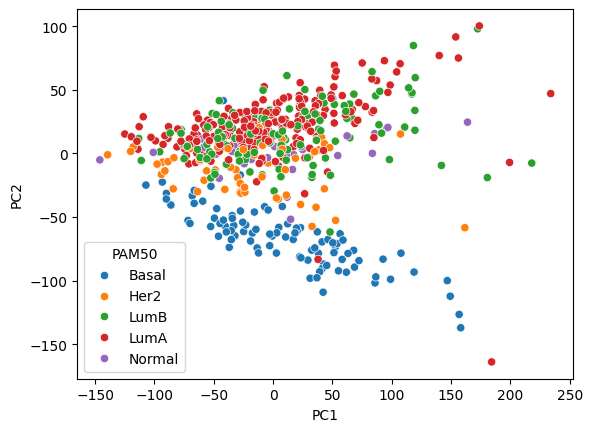

In [199]:
# Seaborn
sns.scatterplot(
    x = 'PC1',
    y = 'PC2',
    hue = 'PAM50',
    data = df_pca_scaled
)

This achieved reasonable clustering of the basal samples, and very poor clustering of the Her2 cells with the rest being a mess. Boo log transforms

I've increased the number of components calculated for the VST data so we can create a scree plot. After viewing the first 2 PCs plotted for both normalization methods, I've decided to abandon the log scaled data and continue with VST scaling as is best practice. It was worth trying the log scaling, but VST is specifically designed for this type of data.

In [203]:
# PCA for VST normalized data
n_components = 10
pca_vst = PCA(n_components=n_components)
pca_result_vst = pca_vst.fit_transform(df_expression_vst)

# VST data prep
df_pca_vst = pd.DataFrame(
    pca_result_vst[:, :n_components],
    columns = [f'PC{i}' for i in range(1, n_components+1)],
    index = df_expression_vst.index
)
df_pca_vst['PAM50'] = df_metadata['PAM50']

pca_vst_variance_ratio = pca_vst.explained_variance_ratio_

<Axes: xlabel='PC1', ylabel='PC2'>

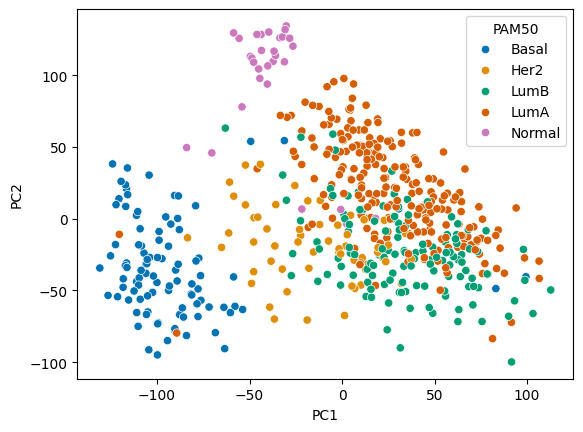

In [204]:
sns.scatterplot(
    x = 'PC1',
    y = 'PC2',
    hue = 'PAM50',
    palette='colorblind',
    data = df_pca_vst
)

Variance stabilizing transformation did a much better job at normalizing our data, which was expected. We see very distinct clusters of Basal and Normal samples, with some mixing of the HER2, LumA, and LumB, but overall, still clustered with samples of the same subtype.

Future improvements: #todo
- Add variance percentages to axis labels
- Add 95% confidence ellipses using a covariance matrix and chi-squared scaling for each subtype cluster
- Clean font + font sizes for readability
- Add title

# Scree Plot

<Axes: >

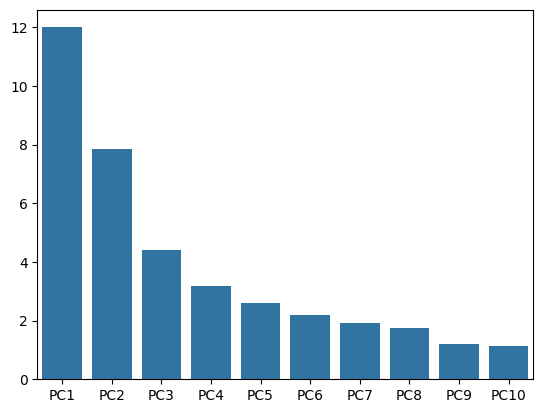

In [205]:
sns.barplot(
    x = [f'PC{i}' for i in range(1,n_components+1)],
    y = pca_vst_variance_ratio * 100
    )

# t-SNE

<Axes: xlabel='tSNE1', ylabel='tSNE2'>

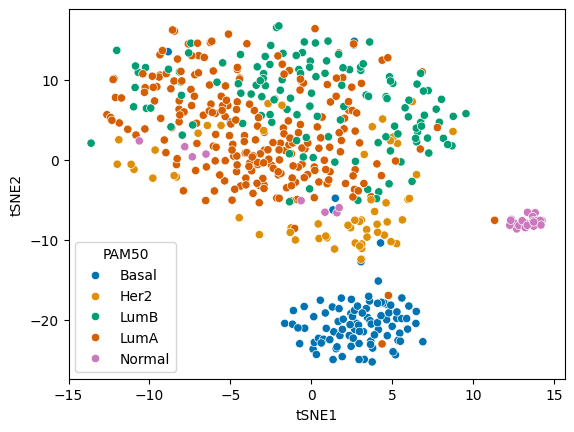

In [ ]:
n_components = 2
tSNE = TSNE(n_components=n_components, perplexity=30, random_state=1)
tSNE_result = tSNE.fit_transform(df_expression_vst)

# Result data prep
df_tSNE = pd.DataFrame(
    tSNE_result[:, :n_components],
    columns = [f'tSNE{i}' for i in range(1, n_components+1)],
    index = df_expression_vst.index
)
df_tSNE['PAM50'] = df_metadata['PAM50']

sns.scatterplot(
    x = 'tSNE1',
    y = 'tSNE2',
    hue = 'PAM50',
    palette = 'colorblind',
    data = df_tSNE
)

# UMAP

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

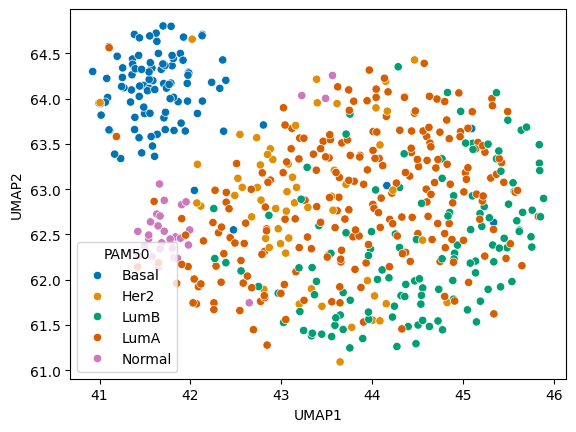

In [ ]:
n_components = 2
umap = UMAP(n_components=n_components, n_neighbors=70, random_state=1)
umap_result = umap.fit_transform(df_expression_vst)

# Result data prep
df_umap = pd.DataFrame(
    umap_result[:, :n_components],
    columns = [f'UMAP{i}' for i in range(1, n_components+1)],
    index = df_expression_vst.index
)
df_umap['PAM50'] = df_metadata['PAM50']

sns.scatterplot(
    x = 'UMAP1',
    y = 'UMAP2',
    hue = 'PAM50',
    palette = 'colorblind',
    data = df_umap
)

I tried a few different values for the n_neightbors parameter in the UMAP. n_neighbors under 50 (5, 15, 30) produced 2 tight isolated clusters with the Basal samples in the opposite corner from the rest of the samples. Increasing the n_neighbors parameter allowed the clusters to expand and allowed patterns within the large cluster to reveal themselves. Within the large cluster it seems that subtypes are roughly grouped together.

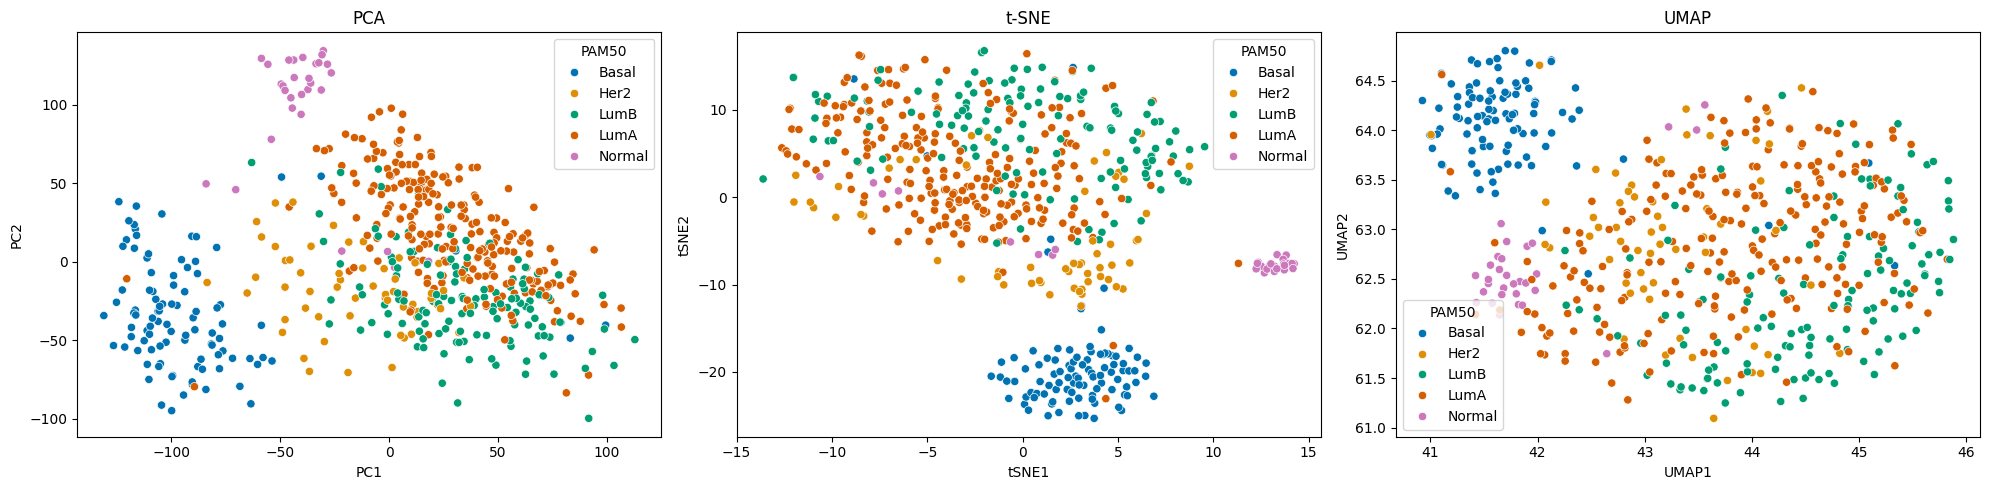

In [228]:
# Compare PCA, t-SNE, and UMAP clustering
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plots = [
    (df_pca_vst, 'PC1', 'PC2', 'PCA', axes[0]),
    (df_tSNE, 'tSNE1', 'tSNE2', 't-SNE', axes[1]),
    (df_umap, 'UMAP1', 'UMAP2', 'UMAP', axes[2])
]

for data, x, y, title, ax in plots:
    sns.scatterplot(
        x = x,
        y = y,
        hue = 'PAM50',
        palette = 'colorblind',
        ax = ax,
        data = data
    )
    ax.set_title(title)

fig.tight_layout()
plt.show()

{'LumB': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'Her2': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'LumA': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), 'Basal': (0.8352941176470589, 0.3686274509803922, 0.0), 'Normal': (0.8, 0.47058823529411764, 0.7372549019607844)}


/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


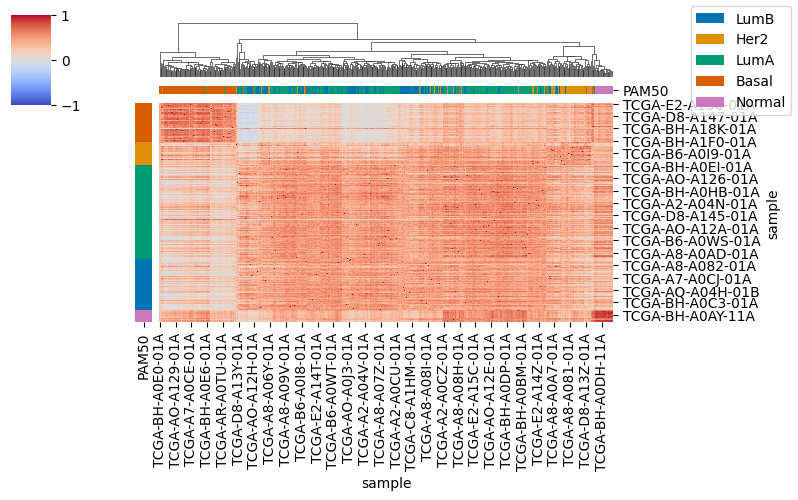

In [ ]:
# Sample variance heatmap
# Filter the dataset to the 500 genes with the most variance
genes500 = df_expression_vst.var().nlargest(500).index
df_expression_500genes = df_expression_vst[genes500]

# Sort df into PAM50 subtypes
genes500_sortedindex = df_metadata['PAM50'].sort_values().index
df_expression_500genes_sorted = df_expression_500genes.loc[genes500_sortedindex]

# Find sample to sample correlation, transpose so samples are columns
sample2sample_correlation = df_expression_500genes_sorted.T.corr()

# Get subtypes and map color to subtypes
subtypes = df_metadata['PAM50'].unique()
palette = sns.color_palette(palette = 'colorblind', n_colors=len(subtypes))
color_map = dict(zip(subtypes, palette))
color_labels = df_metadata['PAM50'].map(color_map)

# Plot heatmap
g = sns.clustermap(
    sample2sample_correlation,
    cmap = 'coolwarm',
    row_colors = color_labels,
    col_colors = color_labels,
    vmin = -1,
    vmax = 1,
    figsize = (8, 5),
    row_cluster = False,
    col_cluster = True
)
# Add legend for colors
patch = [Patch(facecolor=color, label=subtype) for subtype, color in color_map.items()]
g.fig.legend(handles=patch)

Note: colors are not consistent with other charts, fix in future #todo